# Detecting arrythmia using Deep Leaning

## Loading modules

In [1]:
import pandas as pd
import numpy as np
import wfdb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
#os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, LSTM, Dense, Dropout, TimeDistributed
from tensorflow.keras.optimizers import Adam

## Download Dataset

In [3]:
from pathlib import Path
import zipfile

database_filename = "mit-bih-arrhythmia-database-1.0.0.zip"
expected_file = Path("mit-bih-arrhythmia-database-1.0.0")

if not expected_file.exists():
    with zipfile.ZipFile(database_filename, 'r') as zip_ref:
        zip_ref.extractall(".")
    print("Extraction complete.")
else:
    print("Files already extracted.")

Files already extracted.


## Loading data

Loading list of records available, from dataset available [here](https://physionet.org/content/mitdb/1.0.0/)

In [4]:
records = np.loadtxt("mit-bih-arrhythmia-database-1.0.0/RECORDS", dtype=int)

Defining invalid beats as well as abnormal beats, according to [Physiobank](https://archive.physionet.org/physiobank/annotations.shtml)

In [5]:
invalid_beat = [
    "[", "!", "]", "x", "(", ")", "p", "t", 
    "u", "`", "'", "^", "|", "~", "+", "s", 
    "T", "*", "D", "=", '"', "@"
]

abnormal_beats = [
    "L", "R", "B", "A", "a", "J", "S", "V", 
    "r", "F", "e", "j", "n", "E", "/", "f", "Q", "?"
]

## Processing dataset

This function classify a beat according to its symbol and the list provided above.

In [6]:
def classify_beat(symbol):
    if symbol in abnormal_beats:
        return 1
    elif symbol == "N" or symbol == ".":
        return 0    

Given a signal, the beat location, and the window to be used as a sequence, this function gets the sequence. It will return an empty array in case of an invalid beat or empty sequence.

In [7]:
def get_sequence(signal, beat_loc, window_sec, fs):
    window_one_side = window_sec * fs
    beat_start = beat_loc - window_one_side
    beat_end = beat_loc + window_one_side
    if beat_end < signal.shape[0]:
        sequence = signal[beat_start:beat_end, 0]
        return sequence.reshape(1, -1, 1)
    else:
        return np.array([])

The code below will build a list of labels and sequences as well as map the sequences for each patient. The percentage calculated represents the ratio of abnormal beats in each patient data.

In [8]:
all_sequences = []
all_labels = []
window_sec = 3
subject_map = []
for subject in records:
    record = wfdb.rdrecord(f'mit-bih-arrhythmia-database-1.0.0/{subject}')
    annotation = wfdb.rdann(f'mit-bih-arrhythmia-database-1.0.0/{subject}', 'atr')
    atr_symbol = annotation.symbol
    atr_sample = annotation.sample
    fs = record.fs
    scaler = StandardScaler()
    signal = scaler.fit_transform(record.p_signal)
    subject_labels = []
    for i, i_sample in enumerate(atr_sample):
        label = classify_beat(atr_symbol[i])
        sequence = get_sequence(signal, i_sample, window_sec, fs)
        if label is not None and sequence.size > 0:
            all_sequences.append(sequence)
            subject_labels.append(label)

    normal_percentage = sum(subject_labels) / len(subject_labels)
    subject_map.append({
        "subject": subject,
        "percentage": normal_percentage,
        "num_seq": len(subject_labels),
        "start": len(all_labels),
        "end": len(all_labels)+len(subject_labels)
    })
    all_labels.extend(subject_labels)

In [9]:
print(subject_map[:5])

[{'subject': 100, 'percentage': 0.014997794441993825, 'num_seq': 2267, 'start': 0, 'end': 2267}, {'subject': 101, 'percentage': 0.002688172043010753, 'num_seq': 1860, 'start': 2267, 'end': 4127}, {'subject': 102, 'percentage': 0.9546287809349221, 'num_seq': 2182, 'start': 4127, 'end': 6309}, {'subject': 103, 'percentage': 0.0009615384615384616, 'num_seq': 2080, 'start': 6309, 'end': 8389}, {'subject': 104, 'percentage': 0.9266756635177688, 'num_seq': 2223, 'start': 8389, 'end': 10612}]


Creating bins to be used to stratify the train and validation split. 

In [10]:
subject_map = pd.DataFrame(subject_map)

In [11]:
print(subject_map[:5])

   subject  percentage  num_seq  start    end
0      100    0.014998     2267      0   2267
1      101    0.002688     1860   2267   4127
2      102    0.954629     2182   4127   6309
3      103    0.000962     2080   6309   8389
4      104    0.926676     2223   8389  10612


The code presented will create class in each patient is segmented.

In [12]:
bins = [0, 0.2, 0.6, 1.0]
subject_map["bin"] = pd.cut(subject_map['percentage'], bins=bins, labels=False, include_lowest=True)

In [13]:
print(subject_map[:5])

   subject  percentage  num_seq  start    end  bin
0      100    0.014998     2267      0   2267    0
1      101    0.002688     1860   2267   4127    0
2      102    0.954629     2182   4127   6309    2
3      103    0.000962     2080   6309   8389    0
4      104    0.926676     2223   8389  10612    2


Now, the dataset is split into train and validation, stratifying by the bin defined above.

In [14]:
train, validation = train_test_split(subject_map, test_size=0.25, stratify=subject_map["bin"], random_state=42)

This function build a dataset based on the map for each split.

In [15]:
def build_dataset(df, all_sequences, all_labels):
    sequences = []
    labels = []
    for i, row in df.iterrows():
        start = int(row["start"])
        end = int(row["end"])
        sequences.extend(all_sequences[start:end])
        labels.extend(all_labels[start:end])
        
    return np.vstack(sequences), np.vstack(labels)

In [16]:
X_train, y_train = build_dataset(train, all_sequences, all_labels)
X_val, y_val = build_dataset(validation, all_sequences, all_labels)

In [17]:
X_train.shape, y_train.shape

((82964, 1440, 1), (82964, 1))

## Training the model

### CNN model

In [18]:
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from keras.optimizers import Adam

sequence_size = X_train.shape[1]
n_features = 1

cnn_model = Sequential([
    Conv1D(
        filters=16,           # αύξηση των filters για καλύτερο representation
        kernel_size=4,
        strides=1,
        input_shape=(sequence_size, n_features),
        padding="same",
        activation="relu"
    ),
    MaxPooling1D(pool_size=4),  # Κρίσιμη αλλαγή εδώ: μειώνει το μήκος του sequence
    Flatten(),
    Dropout(0.5),
    Dense(1, activation="sigmoid", name="output")
])

optimizer = Adam(learning_rate=0.001)

cnn_model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 1440, 16)          80        
                                                                 
 max_pooling1d (MaxPooling1  (None, 360, 16)           0         
 D)                                                              
                                                                 
 flatten (Flatten)           (None, 5760)              0         
                                                                 
 dropout (Dropout)           (None, 5760)              0         
                                                                 
 output (Dense)              (None, 1)                 5761      
                                                                 
Total params: 5841 (22.82 KB)
Trainable params: 5841 (22.82 KB)
Non-trainable params: 0 (0.00 Byte)
______________________

In [19]:
import json
from tensorflow.keras.models import load_model

train = False
if train:
    hist_cnn = cnn_model.fit(
        X_train, 
        y_train, 
        batch_size=128,
        epochs=15,
        validation_data=(X_val, y_val)
    )
    cnn_model.save('Model4/cnn_model.keras')

    with open('Model4/hist_cnn.json', 'w') as f:
        json.dump(hist_cnn.history, f)

    with open('Model4/hist_cnn.json', 'r') as f:
        hist_cnn = json.load(f)
else:
    cnn_model = load_model('Model4/cnn_model.keras')

    with open('Model4/hist_cnn.json', 'r') as f:
        hist_cnn = json.load(f)

In [20]:
cnn_model.evaluate(X_val, y_val)

822/822 [==============================] - 0s 493us/step - loss: 0.7004 - accuracy: 0.8148


[0.7003799080848694, 0.8148444294929504]

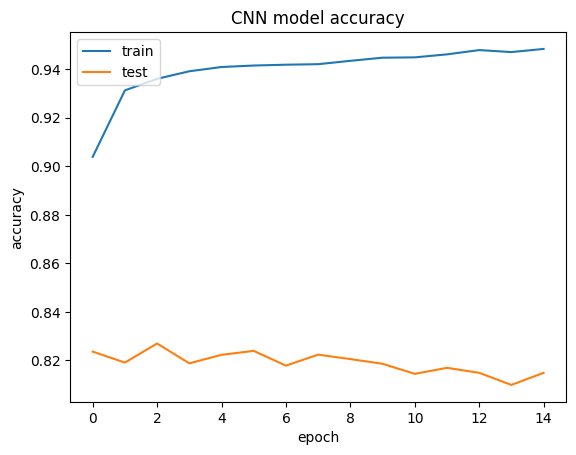

In [21]:
# summarize history for accuracy
plt.plot(hist_cnn['accuracy'])
plt.plot(hist_cnn['val_accuracy'])
plt.title('CNN model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

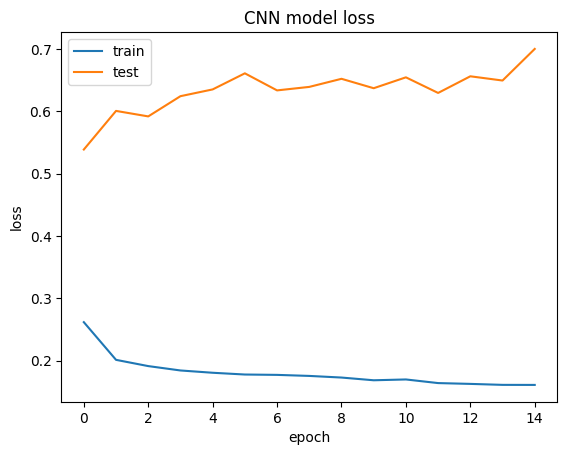

In [22]:
# summarize history for loss
plt.plot(hist_cnn['loss'])
plt.plot(hist_cnn['val_loss'])
plt.title('CNN model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

## Make an hls4ml config & model

In [23]:
import hls4ml
import plotting 

os.environ['PATH'] = os.environ['XILINX_VITIS'] + '/bin:' + os.environ['PATH']

config = hls4ml.utils.config_from_keras_model(cnn_model, granularity='name', backend='Vitis')
config['Model']['Strategy'] = 'Resources'
config['Model']['Precision'] = 'ap_fixed<16,6>'
print("-----------------------------------")
print("Configuration")
plotting.print_dict(config)
print("-----------------------------------")

config['LayerName']['conv1d']['Precision']['weight'] = 'ap_fixed<12,4>'
config['LayerName']['conv1d']['Precision']['bias'] = 'ap_fixed<12,4>'

config['LayerName']['output']['Precision']['weight'] = 'ap_fixed<12,4>'
config['LayerName']['output']['Precision']['bias'] = 'ap_fixed<12,4>'

hls_model = hls4ml.converters.convert_from_keras_model(cnn_model, hls_config=config, backend='Vitis', output_dir='hls4ml/model_4_12b', part='xcu250-figd2104-2L-e', io_type='io_stream')

Interpreting Sequential
Topology:
Layer name: conv1d_input, layer type: InputLayer, input shapes: [[None, 1440, 1]], output shape: [None, 1440, 1]
Layer name: conv1d, layer type: Conv1D, input shapes: [[None, 1440, 1]], output shape: [None, 1440, 16]
Layer name: max_pooling1d, layer type: MaxPooling1D, input shapes: [[None, 1440, 16]], output shape: [None, 360, 16]
Layer name: flatten, layer type: Reshape, input shapes: [[None, 360, 16]], output shape: [None, 5760]
Layer name: output, layer type: Dense, input shapes: [[None, 5760]], output shape: [None, 1]
-----------------------------------
Configuration
Model
  Precision:         ap_fixed<16,6>
  ReuseFactor:       1
  Strategy:          Resources
  BramFactor:        1000000000
  TraceOutput:       False
LayerName
  conv1d_input
    Trace:           False
    Precision
      result:        auto
  conv1d
    Trace:           False
    Precision
      result:        auto
      weight:        auto
      bias:          auto
      accum:

## Visualise the model architecture

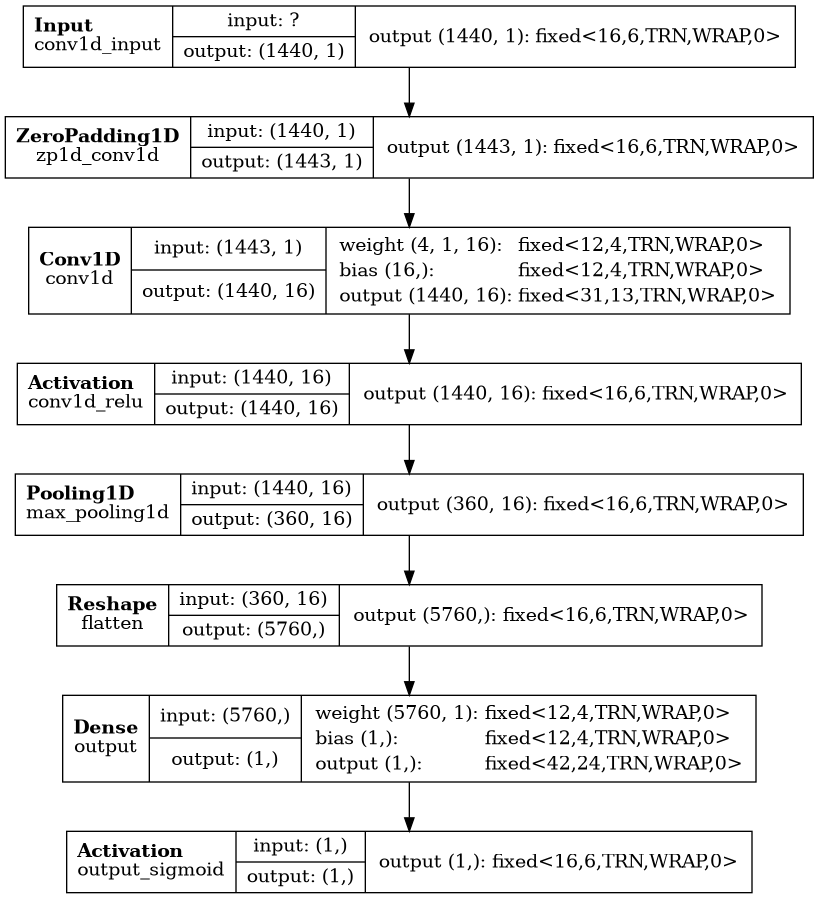

In [24]:
hls4ml.utils.plot_model(hls_model, show_shapes=True, show_precision=True, to_file=None)

## Compile, predict

In [25]:
hls_model.compile()
X_val = np.ascontiguousarray(X_val)
y_hls = hls_model.predict(X_val)

Writing HLS project
Done


## HLS4ML Model Accuracy

In [26]:
from sklearn.metrics import accuracy_score

# Convert predictions to binary labels using a threshold of 0.5
y_hls_pred   = (y_hls > 0.5).astype(int)

# Calculate accuracy using ground truth y_val
acc_hls   = accuracy_score(y_val, y_hls_pred)

print("HLS4ML Model Accuracy: {:.2f}%".format(acc_hls * 100))


HLS4ML Model Accuracy: 81.31%


## Synthesize

In [ ]:
hls_model.build(csim=False, synth=True, vsynth=True, export=True)


****** Vitis HLS - High-Level Synthesis from C, C++ and OpenCL v2023.2 (64-bit)
  **** SW Build 4023990 on Oct 11 2023
  **** IP Build 4028589 on Sat Oct 14 00:45:43 MDT 2023
  **** SharedData Build 4025554 on Tue Oct 10 17:18:54 MDT 2023
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2023 Advanced Micro Devices, Inc. All Rights Reserved.

source /tools/Xilinx/Vitis_HLS/2023.2/scripts/vitis_hls/hls.tcl -notrace
INFO: [HLS 200-10] Running '/tools/Xilinx/Vitis_HLS/2023.2/bin/unwrapped/lnx64.o/vitis_hls'
INFO: [HLS 200-10] For user 'fotis' on host 'fotis-Z390-UD' (Linux_x86_64 version 6.8.0-64-generic) on Sat Jul 19 12:58:57 EEST 2025
INFO: [HLS 200-10] On os Ubuntu 24.04.2 LTS
INFO: [HLS 200-10] In directory '/home/fotis/arrhythmia-detection/hls4ml/model_4_12b'
INFO: [HLS 200-2053] The vitis_hls executable is being deprecated. Consider using vitis-run --mode hls --tcl
Sourcing Tcl script 'build_prj.tcl'
INFO: [HLS 200-1510] Running: open_project mypro

## Check the reports

In [ ]:
hls4ml.report.read_vivado_report('hls4ml/model_4_12b/')